**Cisplatin FF Parameterized via FUERZA Estimation & Subsequent Gradient Optimization**

Cisplatin toy example

In [20]:
import os
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import sys
from matplotlib import animation, rc
from IPython.display import HTML, Image
import seaborn
import pickle
import pandas as pd
from numpy import copy
from scipy import stats
import itertools
from sklearn.metrics import r2_score

seaborn.set_theme(style="whitegrid")

seaborn.set_theme()
seaborn.set_context("paper")
seaborn.set_style('white')
#seaborn.set_style("ticks")
zesty = ['#F5793A', '#A95AA1', '#85C0F9', '#0F2080']
palette = itertools.cycle(seaborn.color_palette(palette=zesty))

#src_dir = os.path.abspath("/home/mmfarrugia/repos/q2mm/q2mm")
sys.path.append("/home/mfarrugi/repos/q2mm/rh-hybrid/schrodinger.ve/lib/python3.8/site-packages/q2mm-0.0.0-py3.8.egg")

#from hybrid_optimizer import PSO_GA
import q2mm.hybrid_optimizer as hybrid_optimizer
from q2mm.hybrid_optimizer import PSO_DE
from tools.plotters import plot_cost_history, plot_contour, plot_surface, plot_summary, Mesher, Designer

from tools.ff_plotting import *



METHODS

In [21]:
bond_cols = ["param_type", "atom1", "atom2", "Equilibrium Value", "Force Constant", "Dipole Moment", "FF"]
angle_cols = ["param_type", "atom1", "atom2", "atom3", "Equilibrium Value", "Force Constant", "FF"]


In [22]:
convergence_criteria = 0.001
num_params = 31

In [23]:
# Gather data on starting point

ffuerza_grad_score = 1.7479001
fuerza_score = 590.5287
ffuerza_score = 107.7652

gamma_fuerza_score = 247.7877
static_score = 260

gamma_fuerza_grad_score = 1.7482
normal_grad_score = 1.7479
fuerza_grad_score = 1.747901

fuerza_label = '{0:.3f}'.format(590.5287)
static_label = '{0:.3f}'.format(260)

fuerza_grad_label = '{0:.3f}'.format(1.7479)
normal_grad_label = '{0:.3f}'.format(1.7479)

score_cols = ["Label", "Weight", "Reference", "Calculated", "Score", "FF"]
skiprows=[0, 379, 380, 381, 382, 383, 384, 385, 386, 387, 388, 389, 390, 391]

static_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/3-eig/eig_static.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='Static: '+str(static_score))
gamma_fuerza_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/gamma_fuerza/eig_gamma.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA: '+str(gamma_fuerza_score))
gamma_fuerza_grad_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/gamma_fuerza/score.gamma.grad.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA: '+str(gamma_fuerza_grad_score))
static_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/3-eig/eig_static.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='Static: '+str(static_score))
normal_grad_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/3-eig/score.static.grad.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA: '+str(0))

ffuerza_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/frankenfuerza/eig_start.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA: '+str(ffuerza_score))
ffuerza_grad_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/frankenfuerza/score.eig.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA: '+str(ffuerza_grad_score))

fuerza_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/3-eig/eig_start.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA: '+str(fuerza_score))
fuerza_grad_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/3-eig/score.eig.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA: '+str(fuerza_grad_score))

bond_rows = np.arange(1860, 1863)
angle_rows = np.arange(1863, 1869)

bond_fuerza_grad = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/3-eig/mm3.eig.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=fuerza_score)
angle_fuerza_grad = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/3-eig/mm3.eig.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=fuerza_score)

base_direc = '/home/mfarrugi/repos/q2mm/cisplatin_gs_ff'


bond_fuerza, gamma_angle_fuerza, param_gamma_fuerza = get_ff_params(base_direc, ['gamma_fuerza'], 'cisplatin_gamma_fuerza.fld', [gamma_fuerza_score], bond_rows, angle_rows, 'FUERZA')

blah, angle_ffuerza, param_ffuerza = get_ff_params('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/frankenfuerza', [''], 'frankenfuerza_H.fld', [ffuerza_score], bond_rows, angle_rows, 'FUERZA')
#bond_fuerza, angle_fuerza, param_fuerza = get_ff_params('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/3-eig', [''], 'cisplatin_fuerza.fld', [fuerza_score], bond_rows, angle_rows, 'FUERZA')

bond_fuerza_grad = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/3-eig/mm3.eig.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=fuerza_grad_score)
angle_fuerza_grad = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/3-eig/mm3.eig.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=fuerza_grad_score)

bond_ffuerza_grad = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/frankenfuerza/mm3.eig.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=ffuerza_grad_score)
angle_ffuerza_grad = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/frankenfuerza/mm3.eig.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=ffuerza_grad_score)

bond_fuerza, angle_fuerza, param_fuerza = get_ff_params(base_direc, ['3-eig'], 'cisplatin_fuerza.fld', [fuerza_score], bond_rows, angle_rows, 'FUERZA')

bond_fuerza = bond_fuerza[0]
angle_fuerza = angle_fuerza[0]
angle_ffuerza = angle_ffuerza[0]
gamma_angle_fuerza = gamma_angle_fuerza[0]

gamma_bond_fuerza_grad = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/gamma_fuerza/mm3.gamma.grad.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=gamma_fuerza_score)
gamma_angle_fuerza_grad = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/gamma_fuerza/mm3.gamma.grad.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=gamma_fuerza_score)

bond_normal_grad = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/3-eig/mm3.static.grad.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=0)
angle_normal_grad = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/3-eig/mm3.static.grad.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=0)

bond_normal = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/1-q/mm3.fld', skiprows=lambda x: x not in bond_rows, delim_whitespace=True, names=bond_cols).assign(FF=0)
angle_normal = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/1-q/mm3.fld', skiprows=lambda x: x not in angle_rows, delim_whitespace=True, names=angle_cols).assign(FF=0)


/tmp/ipykernel_3111076/3327285104.py:23: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  static_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/3-eig/eig_static.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='Static: '+str(static_score))
/tmp/ipykernel_3111076/3327285104.py:24: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  gamma_fuerza_scores = pd.read_csv('/home/mfarrugi/repos/q2mm/cisplatin_gs_ff/gamma_fuerza/eig_gamma.txt', skiprows=skiprows, delim_whitespace=True, names=score_cols).assign(FF='FUERZA: '+str(gamma_fuerza_score))
/tmp/ipykernel_3111076/3327285104.py:25: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  gamma_fuerza_grad_scores = pd.read_csv(

                                Label  Weight  Reference  Calculated    Score  \
0      eig_cisplatin_opt_freq_m06_1-1    0.00     3.0057     13.6876   0.0000   
1      eig_cisplatin_opt_freq_m06_2-1    0.05     0.0000      0.0891   0.0000   
2      eig_cisplatin_opt_freq_m06_2-2    0.10     3.9943      5.1557   0.0000   
3      eig_cisplatin_opt_freq_m06_3-1    0.05     0.0000     -9.2017   0.0006   
4      eig_cisplatin_opt_freq_m06_3-2    0.05     0.0000     -0.0426   0.0000   
..                                ...     ...        ...         ...      ...   
373  eig_cisplatin_opt_freq_m06_27-23    0.05     0.0000      0.0656   0.0000   
374  eig_cisplatin_opt_freq_m06_27-24    0.05     0.0000     -9.9455   0.0007   
375  eig_cisplatin_opt_freq_m06_27-25    0.05     0.0000    -10.1918   0.0007   
376  eig_cisplatin_opt_freq_m06_27-26    0.05     0.0000      1.1217   0.0000   
377  eig_cisplatin_opt_freq_m06_27-27    0.10  4682.5991   3852.8720  18.2129   

                   FF  
0  

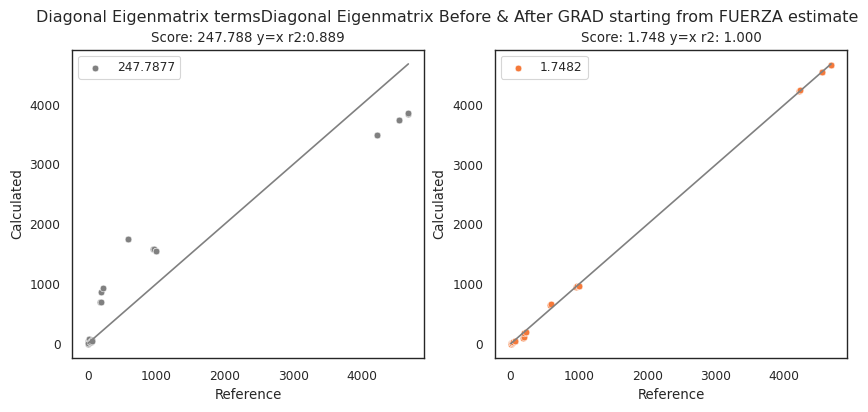

In [24]:
# linear fit diag scores comparison
%matplotlib inline

print(gamma_fuerza_scores)
print(gamma_fuerza_grad_scores)

linear_fit_diag_scores(gamma_fuerza_scores, gamma_fuerza_score, [gamma_fuerza_grad_scores], [gamma_fuerza_grad_score], 'Diagonal Eigenmatrix Before & After GRAD starting from FUERZA estimate')

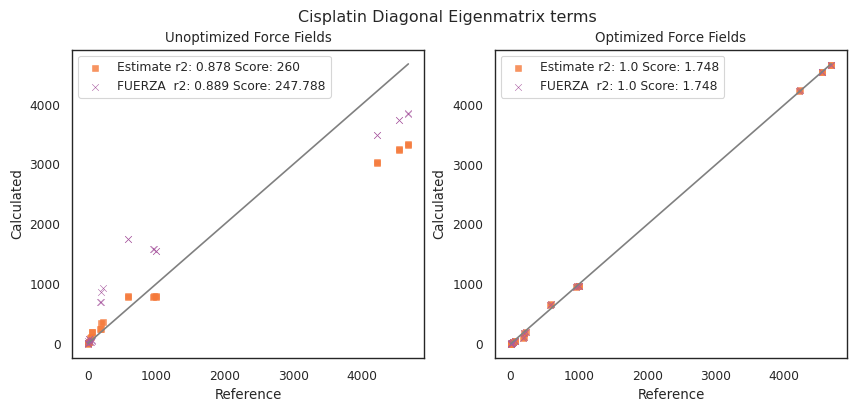

In [25]:
seaborn.set_theme()
seaborn.set_context("paper")
seaborn.set_style('white')
#seaborn.set_style("ticks")
fig, ax = plt.subplots(1, 2, figsize=(10,4))
fig.suptitle('Cisplatin Diagonal Eigenmatrix terms')
palette = itertools.cycle(seaborn.color_palette(palette=zesty))

c1 = next(palette)
c2 = next(palette)

diag_start = static_scores.loc[static_scores['Reference'] != 0.0000]
diag_start = diag_start.loc[diag_start['Weight'] != 0.0000]
#slope, intercept, r2, pv, se = stats.linregress(diag_start['Reference'], diag_start['Calculated'])
r2_ = r2_score(diag_start['Reference'], diag_start['Calculated'])
seaborn.scatterplot(data=diag_start, y='Calculated', x='Reference', color=c1, edgecolor=c1, label='Estimate r2: '+str(np.round(r2_, decimals=3))+' Score: '+str(np.round(static_score, decimals=3)), ax=ax[0], marker='s', alpha = 0.8)

diag_start =gamma_fuerza_scores.loc[gamma_fuerza_scores['Reference'] != 0.0000]
diag_start = diag_start.loc[diag_start['Weight'] != 0.0000]
#slope, intercept, r2, pv, se = stats.linregress(diag_start['Reference'], diag_start['Calculated'])
r2_ = r2_score(diag_start['Reference'], diag_start['Calculated'])
seaborn.scatterplot(data=diag_start, y='Calculated', x='Reference', color=c2, label='FUERZA  r2: '+str(np.round(r2_, decimals=3))+' Score: '+str(np.round(gamma_fuerza_score, decimals=3)), ax=ax[0], marker='x')
ax[0].legend()
ax[0].set_title('Unoptimized Force Fields')

diag_end = normal_grad_scores.loc[normal_grad_scores['Reference'] != 0.0000]
diag_end = diag_end.loc[diag_end['Weight'] != 0.0000]
#slope, intercept, r2, pv, se = stats.linregress(diag_end['Reference'], diag_end['Calculated'])
r2_ = r2_score(diag_end['Reference'], diag_end['Calculated'])
seaborn.scatterplot(data=diag_end, y='Calculated', x='Reference', color=c1, edgecolor=c1, label='Estimate r2: '+str(np.round(r2_, decimals=3))+' Score: '+str(np.round(normal_grad_score, decimals=3)), ax=ax[1], marker='s', alpha=0.8)

diag_end = gamma_fuerza_grad_scores.loc[gamma_fuerza_grad_scores['Reference'] != 0.0000]
diag_end = diag_end.loc[diag_end['Weight'] != 0.0000]
#slope, intercept, r2, pv, se = stats.linregress(diag_end['Reference'], diag_end['Calculated'])
r2_ = r2_score(diag_end['Reference'], diag_end['Calculated'])
seaborn.scatterplot(data=diag_end, y='Calculated', x='Reference', color=c2, label='FUERZA  r2: '+str(np.round(r2_, decimals=3))+' Score: '+str(np.round(gamma_fuerza_grad_score, decimals=3)), ax=ax[1], marker='x')
ax[1].legend()
ax[1].set_title('Optimized Force Fields')

for a in ax:
    seaborn.lineplot(data=diag_start, x='Reference', y='Reference', color='gray', ax=a)

In [26]:
indices_to_check = diag_start.loc[diag_start['Calculated'] - diag_start['Reference'] > 250]
print(indices_to_check)

                                Label  Weight  Reference  Calculated    Score  \
77   eig_cisplatin_opt_freq_m06_12-12     0.1   178.0471    687.8522   6.8757   
90   eig_cisplatin_opt_freq_m06_13-13     0.1   189.3424    694.1139   6.7406   
104  eig_cisplatin_opt_freq_m06_14-14     0.1   198.7942    859.8631  11.5612   
119  eig_cisplatin_opt_freq_m06_15-15     0.1   221.6139    921.6882  12.9657   
135  eig_cisplatin_opt_freq_m06_16-16     0.1   583.4997   1743.0876  35.5726   
152  eig_cisplatin_opt_freq_m06_17-17     0.1   591.7176   1749.8882  35.4857   
170  eig_cisplatin_opt_freq_m06_18-18     0.1   955.9620   1577.7295  10.2274   
189  eig_cisplatin_opt_freq_m06_19-19     0.1   965.7417   1590.3824  10.3221   
209  eig_cisplatin_opt_freq_m06_20-20     0.1   994.9045   1550.7178   8.1727   
230  eig_cisplatin_opt_freq_m06_21-21     0.1  1003.2784   1555.0773   8.0551   

                   FF  
77   FUERZA: 247.7877  
90   FUERZA: 247.7877  
104  FUERZA: 247.7877  
119  FUERZA:

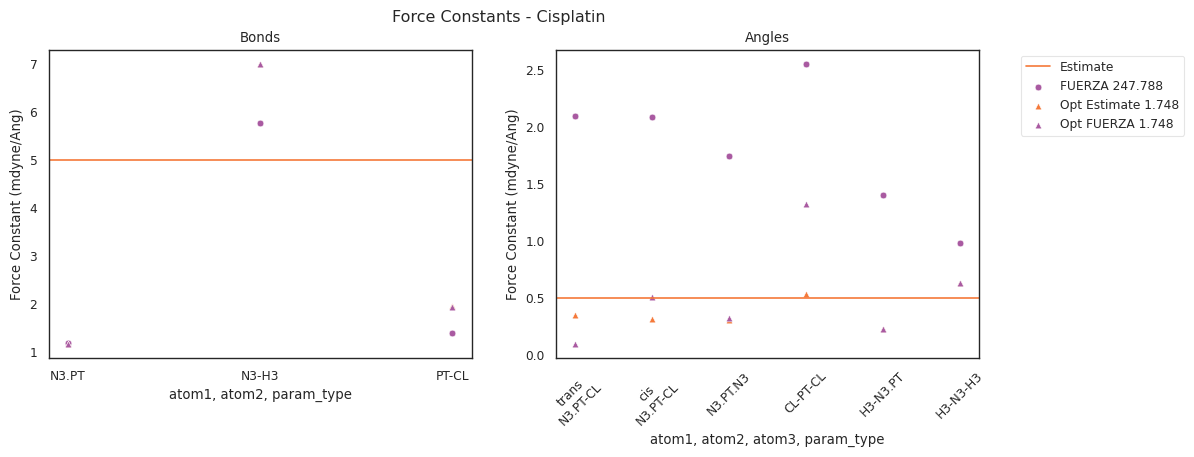

In [27]:
bonds = [bond_fuerza, bond_normal_grad, gamma_bond_fuerza_grad]
angles = [gamma_angle_fuerza, angle_normal_grad, gamma_angle_fuerza_grad]
scores = [gamma_fuerza_score, normal_grad_score, gamma_fuerza_grad_score]
scores = ['FUERZA '+'{0:.3f}'.format(gamma_fuerza_score), 'Opt Estimate '+'{0:.3f}'.format(normal_grad_score), 'Opt FUERZA '+'{0:.3f}'.format(gamma_fuerza_grad_score)]
bond_label_list = ['N3.PT', 'N3-H3', 'PT-CL']
angle_label_list = ['trans\nN3.PT-CL', 'cis\nN3.PT-CL', 'N3.PT.N3', 'CL-PT-CL', 'H3-N3.PT', 'H3-N3-H3']
fig, ax = plot_ff_params_v_static(bonds, angles, scores, ' - Cisplatin', bond_labels=bond_label_list, angles_labels=angle_label_list)

                                Label  Weight  Reference  Calculated    Score  \
0      eig_cisplatin_opt_freq_m06_1-1    0.00     3.0057     13.6876   0.0000   
1      eig_cisplatin_opt_freq_m06_2-1    0.05     0.0000      0.0891   0.0000   
2      eig_cisplatin_opt_freq_m06_2-2    0.10     3.9943      5.1557   0.0000   
3      eig_cisplatin_opt_freq_m06_3-1    0.05     0.0000     -9.2017   0.0006   
4      eig_cisplatin_opt_freq_m06_3-2    0.05     0.0000     -0.0426   0.0000   
..                                ...     ...        ...         ...      ...   
373  eig_cisplatin_opt_freq_m06_27-23    0.05     0.0000      0.0656   0.0000   
374  eig_cisplatin_opt_freq_m06_27-24    0.05     0.0000     -9.9455   0.0007   
375  eig_cisplatin_opt_freq_m06_27-25    0.05     0.0000    -10.1918   0.0007   
376  eig_cisplatin_opt_freq_m06_27-26    0.05     0.0000      1.1217   0.0000   
377  eig_cisplatin_opt_freq_m06_27-27    0.10  4682.5991   3852.8720  18.2129   

                   FF  
0  

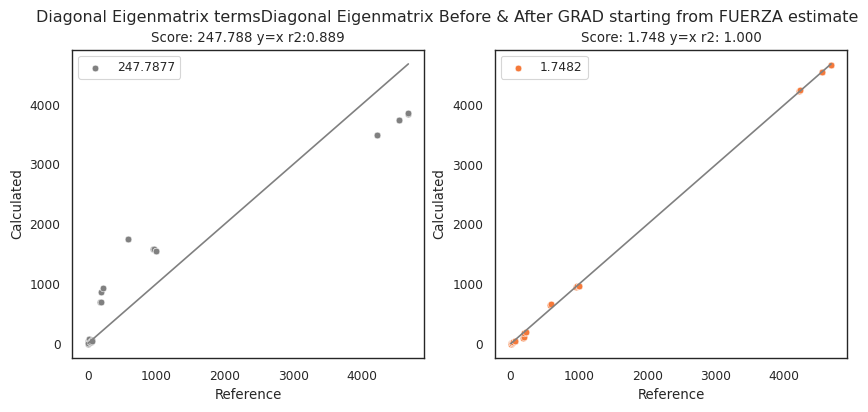

In [28]:
# linear fit diag scores comparison
%matplotlib inline

print(gamma_fuerza_scores)
print(gamma_fuerza_grad_scores)

linear_fit_diag_scores(gamma_fuerza_scores,gamma_fuerza_score, [gamma_fuerza_grad_scores], [gamma_fuerza_grad_score], 'Diagonal Eigenmatrix Before & After GRAD starting from FUERZA estimate')

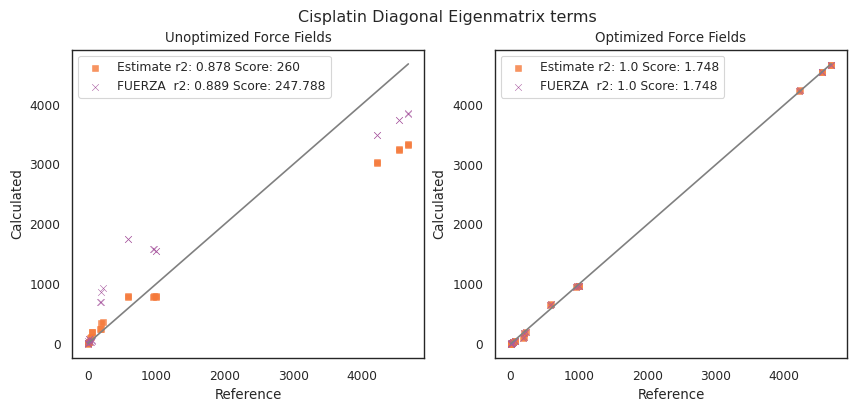

In [29]:
seaborn.set_theme()
seaborn.set_context("paper")
seaborn.set_style('white')
#seaborn.set_style("ticks")
fig, ax = plt.subplots(1, 2, figsize=(10,4))
fig.suptitle('Cisplatin Diagonal Eigenmatrix terms')
palette = itertools.cycle(seaborn.color_palette(palette=zesty))

c1 = next(palette)
c2 = next(palette)

diag_start = static_scores.loc[static_scores['Reference'] != 0.0000]
diag_start = diag_start.loc[diag_start['Weight'] != 0.0000]
#slope, intercept, r2, pv, se = stats.linregress(diag_start['Reference'], diag_start['Calculated'])
r2_ = r2_score(diag_start['Reference'], diag_start['Calculated'])
seaborn.scatterplot(data=diag_start, y='Calculated', x='Reference', color=c1, edgecolor=c1, label='Estimate r2: '+str(np.round(r2_, decimals=3))+' Score: '+str(np.round(static_score, decimals=3)), ax=ax[0], marker='s', alpha = 0.8)

diag_start =gamma_fuerza_scores.loc[gamma_fuerza_scores['Reference'] != 0.0000]
diag_start = diag_start.loc[diag_start['Weight'] != 0.0000]
#slope, intercept, r2, pv, se = stats.linregress(diag_start['Reference'], diag_start['Calculated'])
r2_ = r2_score(diag_start['Reference'], diag_start['Calculated'])
seaborn.scatterplot(data=diag_start, y='Calculated', x='Reference', color=c2, label='FUERZA  r2: '+str(np.round(r2_, decimals=3))+' Score: '+str(np.round(gamma_fuerza_score, decimals=3)), ax=ax[0], marker='x')
ax[0].legend()
ax[0].set_title('Unoptimized Force Fields')

diag_end = normal_grad_scores.loc[normal_grad_scores['Reference'] != 0.0000]
diag_end = diag_end.loc[diag_end['Weight'] != 0.0000]
#slope, intercept, r2, pv, se = stats.linregress(diag_end['Reference'], diag_end['Calculated'])
r2_ = r2_score(diag_end['Reference'], diag_end['Calculated'])
seaborn.scatterplot(data=diag_end, y='Calculated', x='Reference', color=c1, edgecolor=c1, label='Estimate r2: '+str(np.round(r2_, decimals=3))+' Score: '+str(np.round(normal_grad_score, decimals=3)), ax=ax[1], marker='s', alpha=0.8)

diag_end = gamma_fuerza_grad_scores.loc[gamma_fuerza_grad_scores['Reference'] != 0.0000]
diag_end = diag_end.loc[diag_end['Weight'] != 0.0000]
#slope, intercept, r2, pv, se = stats.linregress(diag_end['Reference'], diag_end['Calculated'])
r2_ = r2_score(diag_end['Reference'], diag_end['Calculated'])
seaborn.scatterplot(data=diag_end, y='Calculated', x='Reference', color=c2, label='FUERZA  r2: '+str(np.round(r2_, decimals=3))+' Score: '+str(np.round(gamma_fuerza_grad_score, decimals=3)), ax=ax[1], marker='x')
ax[1].legend()
ax[1].set_title('Optimized Force Fields')

for a in ax:
    seaborn.lineplot(data=diag_start, x='Reference', y='Reference', color='gray', ax=a)

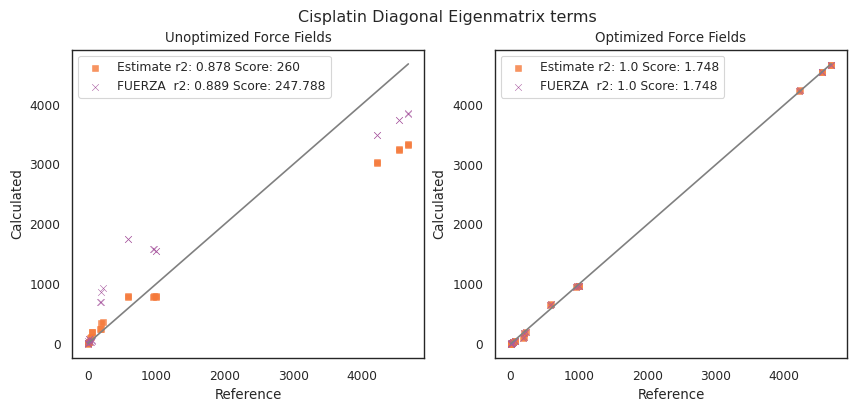

In [30]:
seaborn.set_theme()
seaborn.set_context("paper")
seaborn.set_style('white')
#seaborn.set_style("ticks")
fig, ax = plt.subplots(1, 2, figsize=(10,4))
fig.suptitle('Cisplatin Diagonal Eigenmatrix terms')
palette = itertools.cycle(seaborn.color_palette(palette=zesty))

c1 = next(palette)
c2 = next(palette)

diag_start = static_scores.loc[static_scores['Reference'] != 0.0000]
diag_start = diag_start.loc[diag_start['Weight'] != 0.0000]
#slope, intercept, r2, pv, se = stats.linregress(diag_start['Reference'], diag_start['Calculated'])
r2_ = r2_score(diag_start['Reference'], diag_start['Calculated'])
seaborn.scatterplot(data=diag_start, y='Calculated', x='Reference', color=c1, edgecolor=c1, label='Estimate r2: '+str(np.round(r2_, decimals=3))+' Score: '+str(np.round(static_score, decimals=3)), ax=ax[0], marker='s', alpha = 0.8)

diag_start =gamma_fuerza_scores.loc[gamma_fuerza_scores['Reference'] != 0.0000]
diag_start = diag_start.loc[diag_start['Weight'] != 0.0000]
#slope, intercept, r2, pv, se = stats.linregress(diag_start['Reference'], diag_start['Calculated'])
r2_ = r2_score(diag_start['Reference'], diag_start['Calculated'])
seaborn.scatterplot(data=diag_start, y='Calculated', x='Reference', color=c2, label='FUERZA  r2: '+str(np.round(r2_, decimals=3))+' Score: '+str(np.round(gamma_fuerza_score, decimals=3)), ax=ax[0], marker='x')
ax[0].legend()
ax[0].set_title('Unoptimized Force Fields')

diag_end = normal_grad_scores.loc[normal_grad_scores['Reference'] != 0.0000]
diag_end = diag_end.loc[diag_end['Weight'] != 0.0000]
#slope, intercept, r2, pv, se = stats.linregress(diag_end['Reference'], diag_end['Calculated'])
r2_ = r2_score(diag_end['Reference'], diag_end['Calculated'])
seaborn.scatterplot(data=diag_end, y='Calculated', x='Reference', color=c1, edgecolor=c1, label='Estimate r2: '+str(np.round(r2_, decimals=3))+' Score: '+str(np.round(normal_grad_score, decimals=3)), ax=ax[1], marker='s', alpha=0.8)

diag_end = gamma_fuerza_grad_scores.loc[gamma_fuerza_grad_scores['Reference'] != 0.0000]
diag_end = diag_end.loc[diag_end['Weight'] != 0.0000]
#slope, intercept, r2, pv, se = stats.linregress(diag_end['Reference'], diag_end['Calculated'])
r2_ = r2_score(diag_end['Reference'], diag_end['Calculated'])
seaborn.scatterplot(data=diag_end, y='Calculated', x='Reference', color=c2, label='FUERZA  r2: '+str(np.round(r2_, decimals=3))+' Score: '+str(np.round(gamma_fuerza_grad_score, decimals=3)), ax=ax[1], marker='x')
ax[1].legend()
ax[1].set_title('Optimized Force Fields')

for a in ax:
    seaborn.lineplot(data=diag_start, x='Reference', y='Reference', color='gray', ax=a)

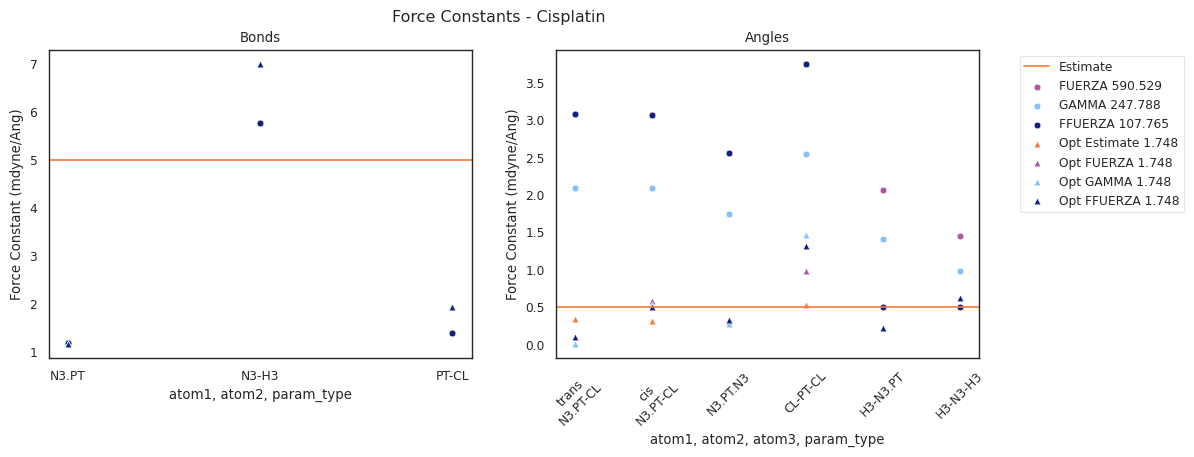

In [31]:
bonds = [bond_fuerza, bond_fuerza, bond_fuerza, bond_normal_grad, bond_fuerza_grad, gamma_bond_fuerza_grad, bond_ffuerza_grad]
angles = [angle_fuerza, gamma_angle_fuerza, angle_ffuerza, angle_normal_grad, angle_fuerza_grad, angle_ffuerza_grad, gamma_angle_fuerza_grad]
scores = ['FUERZA '+'{0:.3f}'.format(fuerza_score), 'GAMMA '+'{0:.3f}'.format(gamma_fuerza_score), 'FFUERZA '+'{0:.3f}'.format(ffuerza_score), 'Opt Estimate '+'{0:.3f}'.format(normal_grad_score), 'Opt FUERZA '+'{0:.3f}'.format(fuerza_grad_score), 'Opt GAMMA '+'{0:.3f}'.format(gamma_fuerza_grad_score), 'Opt FFUERZA '+'{0:.3f}'.format(ffuerza_grad_score)]
bond_label_list = ['N3.PT', 'N3-H3', 'PT-CL']
angle_label_list = ['trans\nN3.PT-CL', 'cis\nN3.PT-CL', 'N3.PT.N3', 'CL-PT-CL', 'H3-N3.PT', 'H3-N3-H3']
fig, ax = plot_ff_params_v_static(bonds, angles, scores, ' - Cisplatin', bond_labels=bond_label_list, angles_labels=angle_label_list)

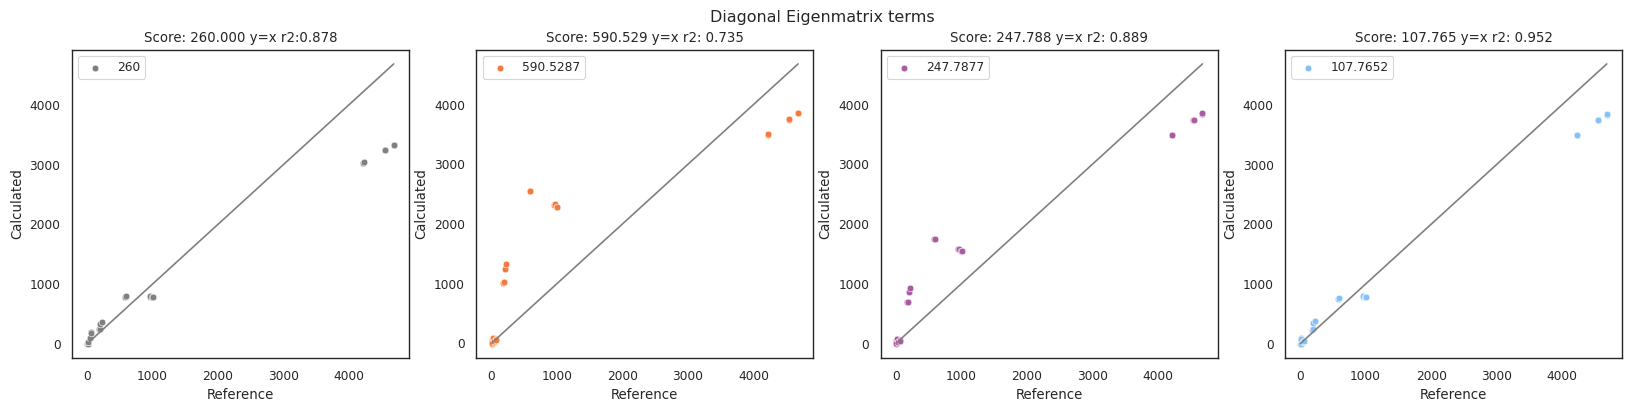

In [32]:
linear_fit_diag_scores(static_scores, static_score, [fuerza_scores, gamma_fuerza_scores, ffuerza_scores], [fuerza_score, gamma_fuerza_score, ffuerza_score])

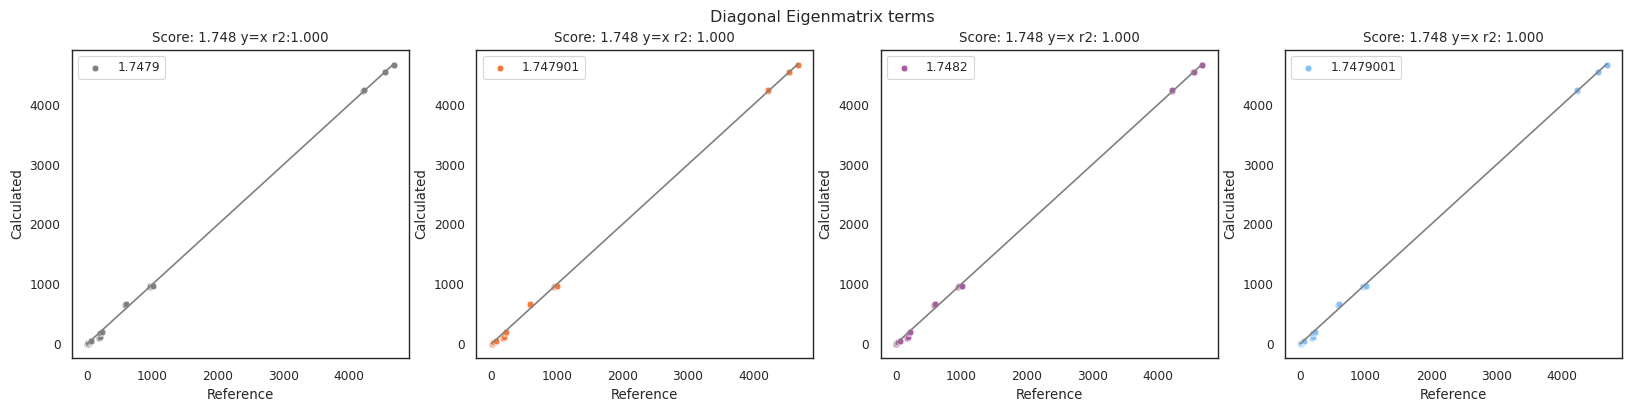

In [33]:
linear_fit_diag_scores(normal_grad_scores, normal_grad_score, [fuerza_grad_scores, gamma_fuerza_grad_scores, ffuerza_grad_scores], [fuerza_grad_score, gamma_fuerza_grad_score, ffuerza_grad_score])

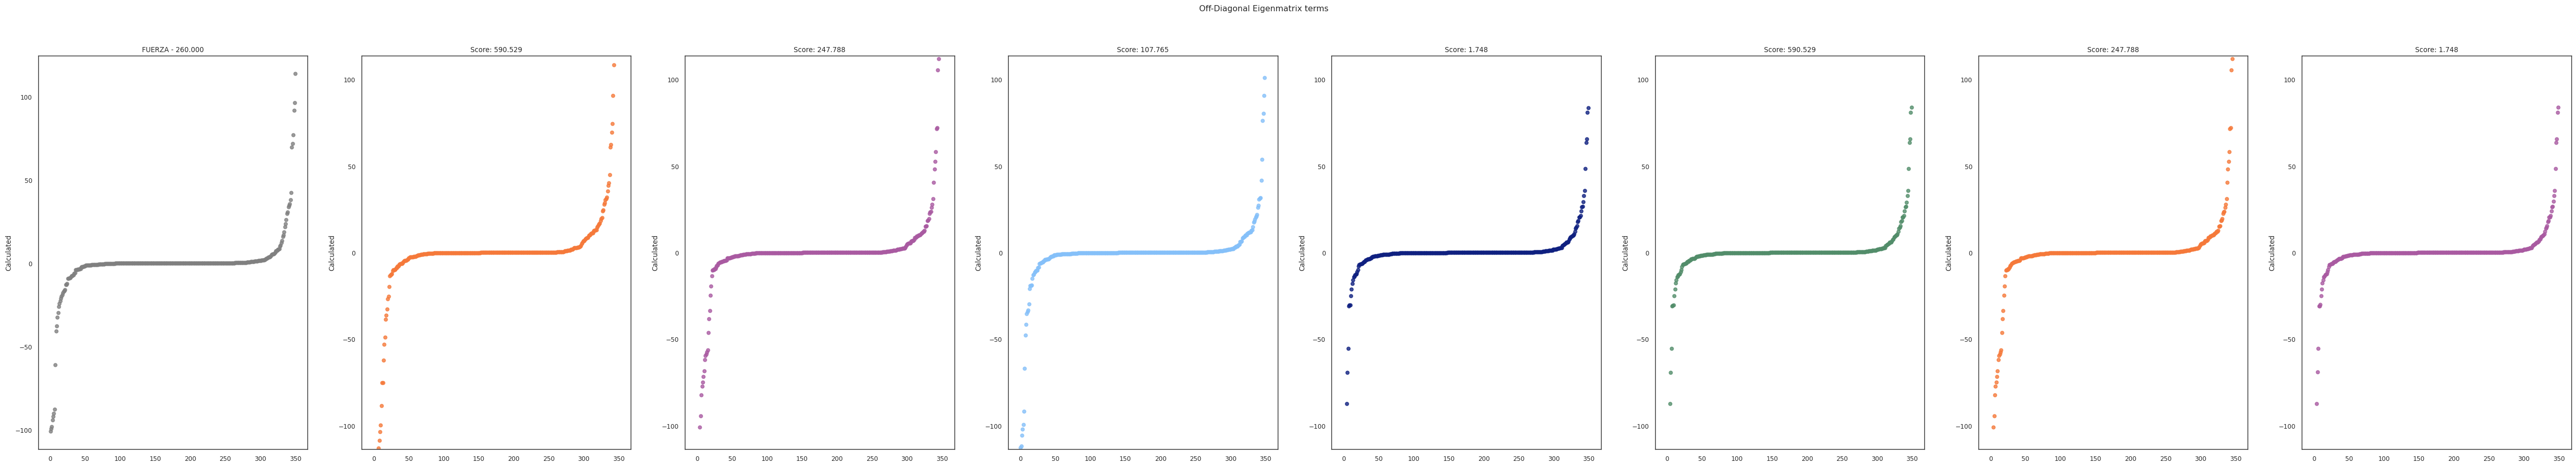

In [34]:
runs = [fuerza_scores, gamma_fuerza_scores, ffuerza_scores, normal_grad_scores, fuerza_grad_scores, gamma_fuerza_scores, ffuerza_grad_scores]
final_scores = [fuerza_score, gamma_fuerza_score, ffuerza_score, normal_grad_score, fuerza_score, gamma_fuerza_score, ffuerza_grad_score]
plot_off_diag_scatter(static_scores, static_score, runs, final_scores)

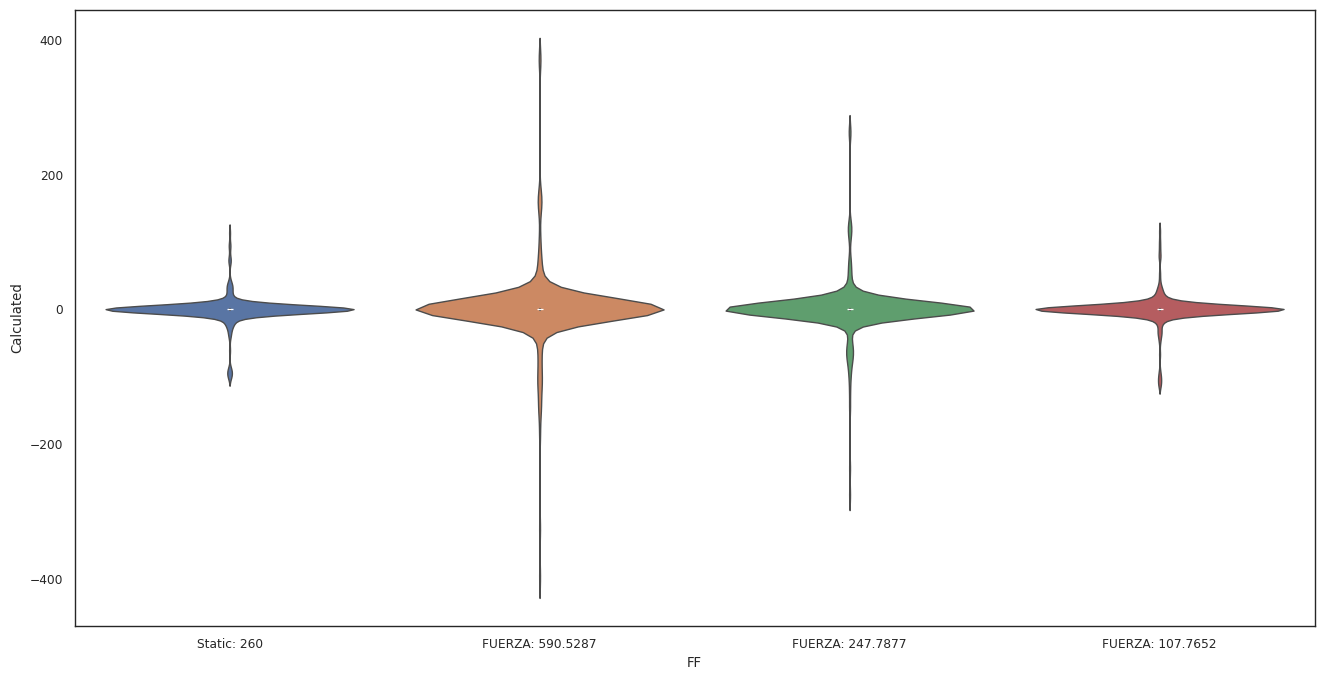

In [35]:
plot_off_diag_violin(static_scores, static_score, runs[:3], final_scores[:3])

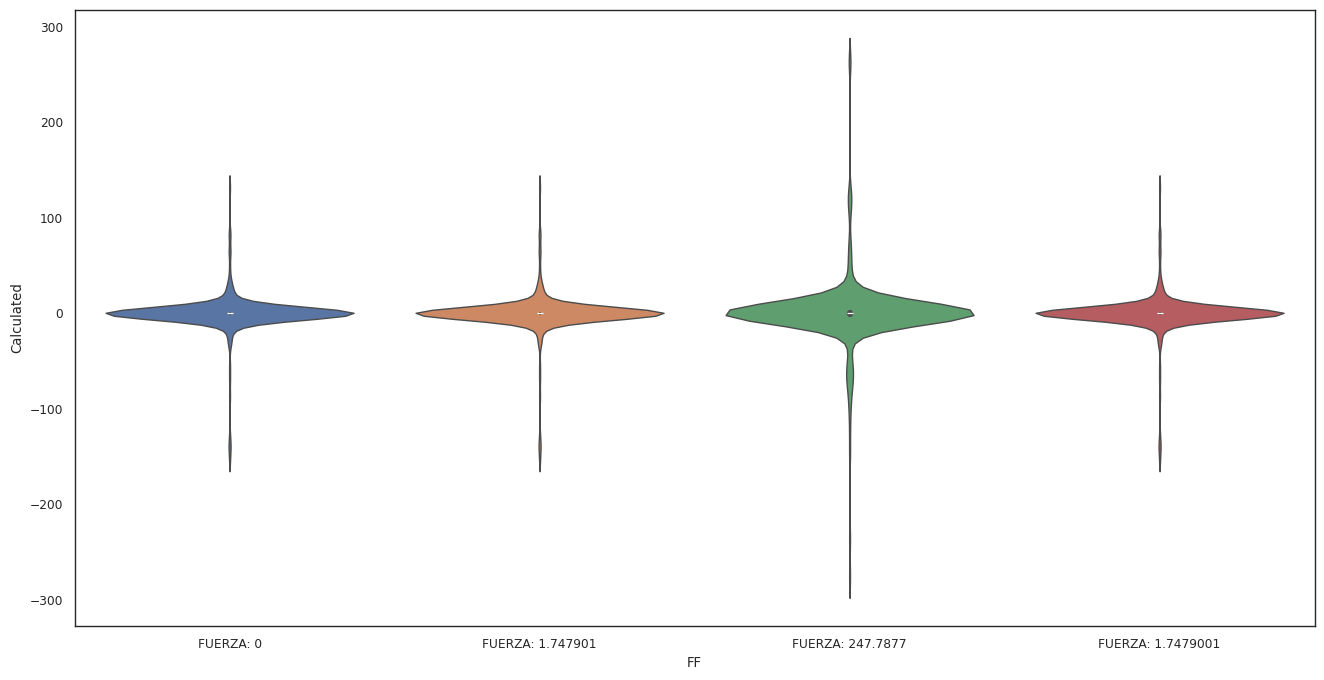

In [36]:
plot_off_diag_violin(normal_grad_scores, normal_grad_score, runs[4:], final_scores[4:])

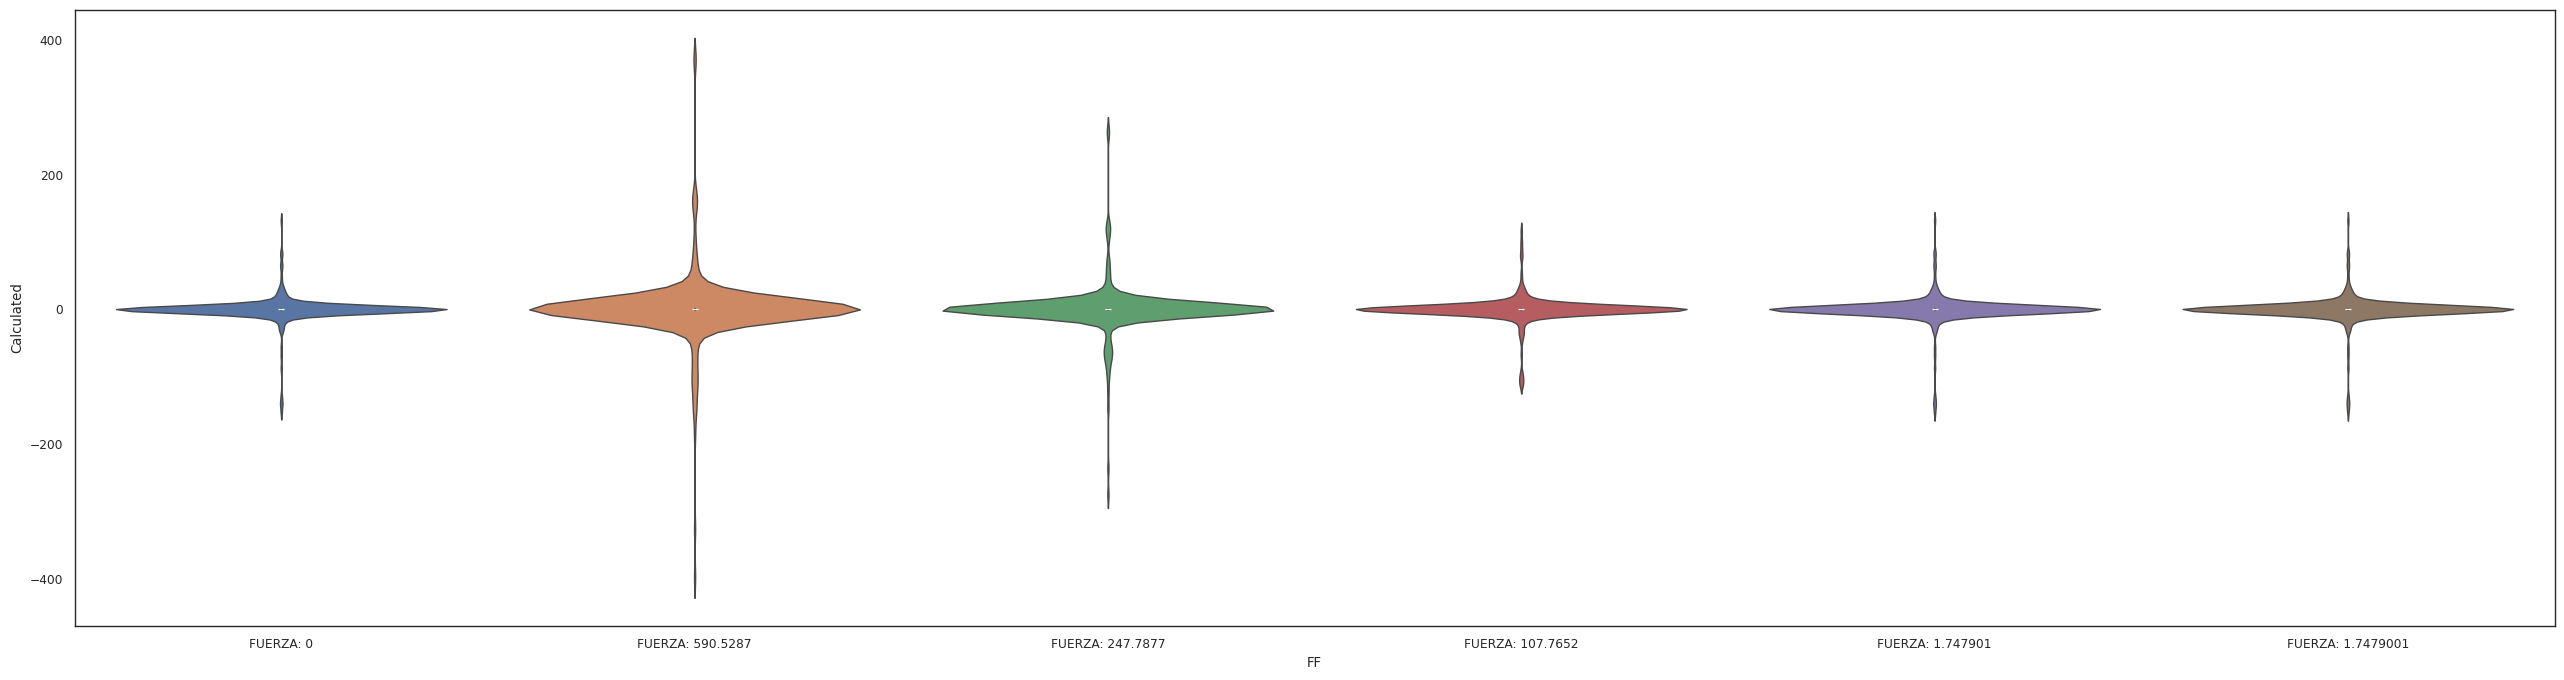

In [37]:
plot_off_diag_violin(normal_grad_scores, normal_grad_score, runs, final_scores)

In [38]:
indices_to_check = diag_start.loc[diag_start['Calculated'] - diag_start['Reference'] > 250]
print(indices_to_check)

                                Label  Weight  Reference  Calculated    Score  \
77   eig_cisplatin_opt_freq_m06_12-12     0.1   178.0471    687.8522   6.8757   
90   eig_cisplatin_opt_freq_m06_13-13     0.1   189.3424    694.1139   6.7406   
104  eig_cisplatin_opt_freq_m06_14-14     0.1   198.7942    859.8631  11.5612   
119  eig_cisplatin_opt_freq_m06_15-15     0.1   221.6139    921.6882  12.9657   
135  eig_cisplatin_opt_freq_m06_16-16     0.1   583.4997   1743.0876  35.5726   
152  eig_cisplatin_opt_freq_m06_17-17     0.1   591.7176   1749.8882  35.4857   
170  eig_cisplatin_opt_freq_m06_18-18     0.1   955.9620   1577.7295  10.2274   
189  eig_cisplatin_opt_freq_m06_19-19     0.1   965.7417   1590.3824  10.3221   
209  eig_cisplatin_opt_freq_m06_20-20     0.1   994.9045   1550.7178   8.1727   
230  eig_cisplatin_opt_freq_m06_21-21     0.1  1003.2784   1555.0773   8.0551   

                   FF  
77   FUERZA: 247.7877  
90   FUERZA: 247.7877  
104  FUERZA: 247.7877  
119  FUERZA: